# Détection automatique des émotions dans un texte (GoEmotions)

## Objectif
L’objectif de ce projet est de construire un système de Machine Learning capable de détecter l’émotion exprimée dans un texte en anglais.

Nous utilisons le dataset GoEmotions de Google Research contenant 28 émotions différentes.

Le problème est formulé comme un problème de classification supervisée multi-classes.


##Importation des bibliothèques

In [103]:

import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


## Chargement du dataset & Analyse de la structure des données

Les fichiers train, dev et test sont chargés directement depuis GitHub.

Chaque ligne contient :
- Le texte
- Les identifiants des émotions (label_ids)
- Un identifiant unique

Le dataset est initialement multi-label (plusieurs émotions possibles par texte).



In [104]:
train_url = "https://raw.githubusercontent.com/google-research/google-research/master/goemotions/data/train.tsv"
dev_url   = "https://raw.githubusercontent.com/google-research/google-research/master/goemotions/data/dev.tsv"
test_url  = "https://raw.githubusercontent.com/google-research/google-research/master/goemotions/data/test.tsv"

train = pd.read_csv(train_url, sep="\t", header=None)
dev   = pd.read_csv(dev_url, sep="\t", header=None)
test  = pd.read_csv(test_url, sep="\t", header=None)

#Renaming the columns
train.columns = ["text", "label_ids", "id"]
dev.columns   = ["text", "label_ids", "id"]
test.columns  = ["text", "label_ids", "id"]

train.head(10)

,text,label_ids,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj
5,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,26,edvnz26
6,Yes I heard abt the f bombs! That has to be wh...,15,ee3b6wu
7,We need more boards and to create a bit more s...,"8,20",ef4qmod
8,Damn youtube and outrage drama is super lucrat...,0,ed8wbdn
9,It might be linked to the trust factor of your...,27,eczgv1o


In [105]:
train.info()
print("VÉRIFICATION DES VALEURS MANQUANTES")
print("Train :", train.isnull().sum().sum(), "valeurs manquantes")
print("Dev   :", dev.isnull().sum().sum(), "valeurs manquantes")
print("Test  :", test.isnull().sum().sum(), "valeurs manquantes")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43410 entries, 0 to 43409
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       43410 non-null  object
 1   label_ids  43410 non-null  object
 2   id         43410 non-null  object
dtypes: object(3)
memory usage: 1017.6+ KB
VÉRIFICATION DES VALEURS MANQUANTES
Train : 0 valeurs manquantes
Dev   : 0 valeurs manquantes
Test  : 0 valeurs manquantes


## Conversion des identifiants en noms d’émotions

In [106]:
emotions_url = "https://raw.githubusercontent.com/google-research/google-research/master/goemotions/data/emotions.txt"

emotions = pd.read_csv(emotions_url, header=None)[0].tolist()

print(emotions)
print("Number of emotions:", len(emotions))


['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
Number of emotions: 28


In [107]:

def convert_ids_to_lists(label_ids):
    ids = [int(i) for i in label_ids.split(",")]
    labels = [emotions[i] for i in ids]
    return ids, labels

# Apply transformation
train[["label_ids_list", "labels"]] = train["label_ids"].apply(
    lambda x: pd.Series(convert_ids_to_lists(x))
)

dev[["label_ids_list", "labels"]] = dev["label_ids"].apply(
    lambda x: pd.Series(convert_ids_to_lists(x))
)

test[["label_ids_list", "labels"]] = test["label_ids"].apply(
    lambda x: pd.Series(convert_ids_to_lists(x))
)

# Explode both columns
train = train.explode(["label_ids_list", "labels"])
dev   = dev.explode(["label_ids_list", "labels"])
test  = test.explode(["label_ids_list", "labels"])

# Create final columns
train["label"]    = train["labels"]
train["label_id"] = train["label_ids_list"]

dev["label"]    = dev["labels"]
dev["label_id"] = dev["label_ids_list"]

test["label"]    = test["labels"]
test["label_id"] = test["label_ids_list"]


# Reset index
train = train.reset_index(drop=True)
dev   = dev.reset_index(drop=True)
test  = test.reset_index(drop=True)

train = train.drop(columns=["label_ids", "label_ids_list", "labels"], errors="ignore")
dev   = dev.drop(columns=["label_ids", "label_ids_list", "labels"], errors="ignore")
test  = test.drop(columns=["label_ids", "label_ids_list", "labels"], errors="ignore")

# Check result
train.head(10)

,text,id,label,label_id
0,My favourite food is anything I didn't have to...,eebbqej,neutral,27
1,"Now if he does off himself, everyone will thin...",ed00q6i,neutral,27
2,WHY THE FUCK IS BAYLESS ISOING,eezlygj,anger,2
3,To make her feel threatened,ed7ypvh,fear,14
4,Dirty Southern Wankers,ed0bdzj,annoyance,3
5,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,edvnz26,surprise,26
6,Yes I heard abt the f bombs! That has to be wh...,ee3b6wu,gratitude,15
7,We need more boards and to create a bit more s...,ef4qmod,desire,8
8,We need more boards and to create a bit more s...,ef4qmod,optimism,20
9,Damn youtube and outrage drama is super lucrat...,ed8wbdn,admiration,0


## Analyse de la distribution des émotions

In [108]:
train["label"].value_counts()

,count
label,
neutral,14219
admiration,4130
approval,2939
gratitude,2662
annoyance,2470
amusement,2328
curiosity,2191
love,2086
disapproval,2022


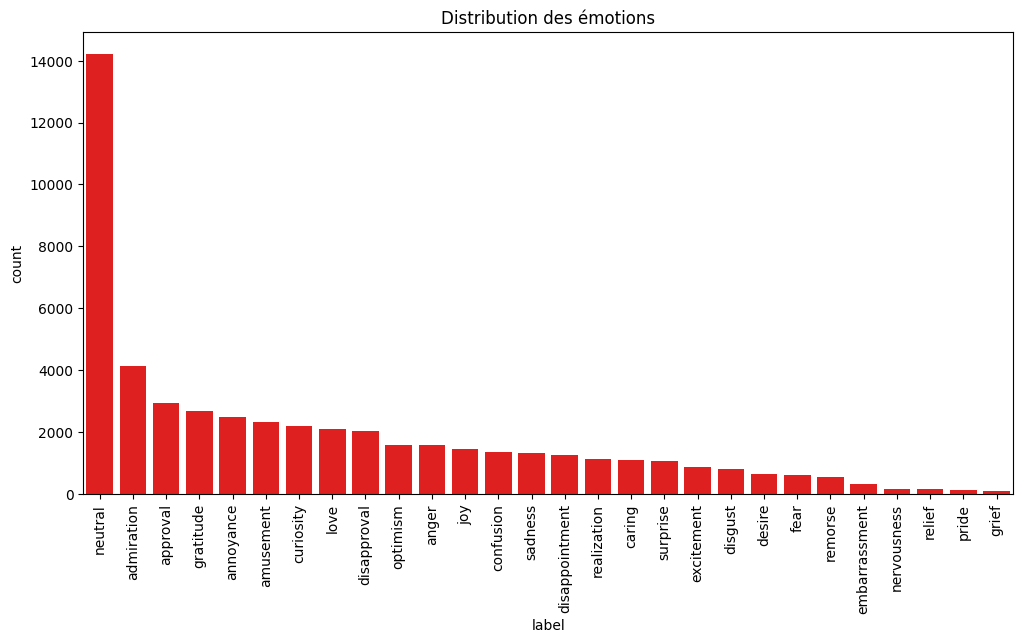

In [109]:
plt.figure(figsize=(12,6))
sns.countplot(x="label", data=train,
              order=train["label"].value_counts().index, color='r')
plt.xticks(rotation=90)
plt.title("Distribution des émotions")
plt.show()


On observe un déséquilibre entre les classes.
Certaines émotions sont très fréquentes tandis que d'autres sont rares.
Cela peut impacter les performances des modèles.

## Nettoyage et prétraitement du texte

Dans cette étape, nous avons appliqué plusieurs opérations de nettoyage sur les textes afin de les rendre exploitables par les modèles de Machine Learning.

Les transformations effectuées sont :

- Conversion du texte en minuscules
- Suppression des caractères spéciaux et des chiffres
- Suppression des mots vides (stopwords) qui n’apportent pas de sens
- Lemmatisation des mots (réduction des mots à leur forme de base)

Ces étapes permettent de réduire le bruit dans les données et d’améliorer la qualité des caractéristiques utilisées pour l’apprentissage.

In [110]:
import re
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Fonction pour convertir les tags nltk vers wordnet
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def clean_text(text):
    text = text.lower()
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"[^a-z\s]", "", text)

    words = text.split()

    # POS tagging
    tagged_words = pos_tag(words)

    # Lemmatization avec POS + suppression stopwords
    words = [
        lemmatizer.lemmatize(w, get_wordnet_pos(tag))
        for w, tag in tagged_words
        if w not in stop_words
    ]

    return " ".join(words)

train["clean_text"] = train["text"].apply(clean_text)
dev["clean_text"] = dev["text"].apply(clean_text)
test["clean_text"]  = test["text"].apply(clean_text)

train.head()
# Vérification
for i in range(5):
    print("Avant :", train["text"].iloc[i])
    print("Après :", train["clean_text"].iloc[i])
    print()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Avant : My favourite food is anything I didn't have to cook myself.
Après : favourite food anything didnt cook

Avant : Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
Après : everyone think he laugh screwing people instead actually dead

Avant : WHY THE FUCK IS BAYLESS ISOING
Après : fuck bayless isoing

Avant : To make her feel threatened
Après : make feel threaten

Avant : Dirty Southern Wankers
Après : dirty southern wanker



#ANALYSE DE LA LONGUEUR DES TEXTES

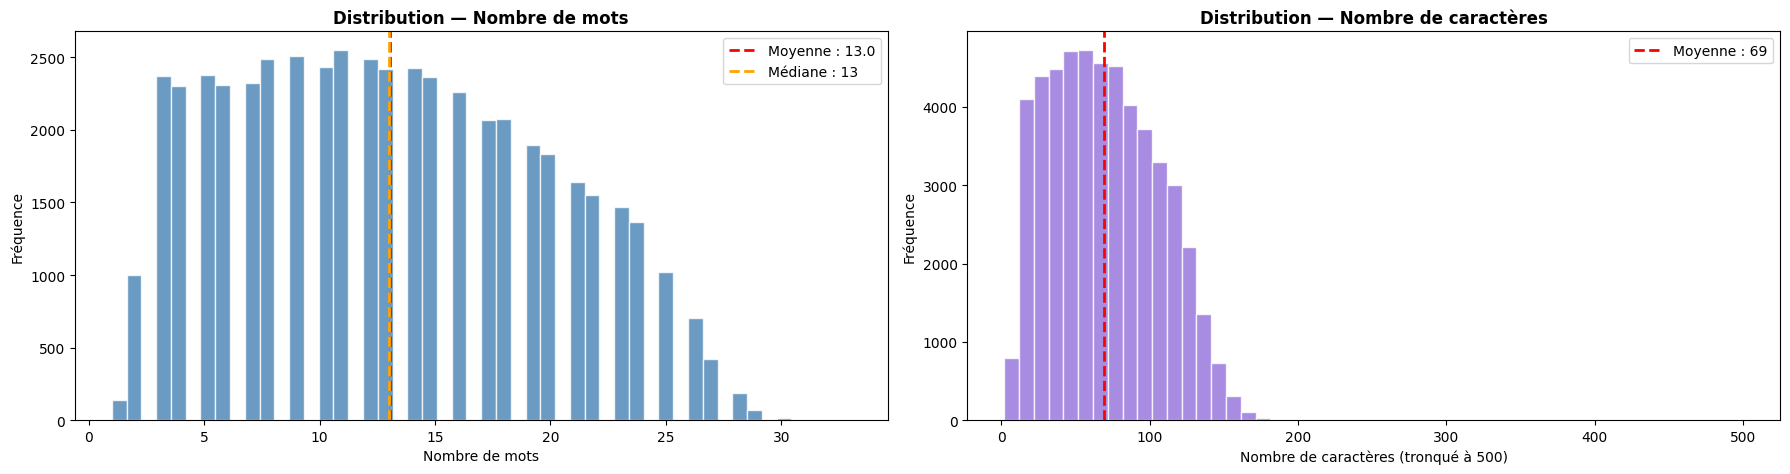


📊 Statistiques descriptives — Longueur des textes (nb de mots) :
count    51103.00
mean        13.03
std          6.69
min          1.00
25%          7.00
50%         13.00
75%         18.00
max         33.00


In [111]:

#  ANALYSE DE LA LONGUEUR DES TEXTES


# Calcul des métriques de longueur
train["nb_mots"]      = train["text"].apply(lambda x: len(str(x).split()))
train["nb_caracteres"] = train["text"].apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── Distribution du nombre de mots ──
axes[0].hist(train["nb_mots"], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(train["nb_mots"].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne : {train["nb_mots"].mean():.1f}')
axes[0].axvline(train["nb_mots"].median(), color='orange', linestyle='--', linewidth=2, label=f'Médiane : {train["nb_mots"].median():.0f}')
axes[0].set_title("Distribution — Nombre de mots", fontweight='bold')
axes[0].set_xlabel("Nombre de mots")
axes[0].set_ylabel("Fréquence")
axes[0].legend()


# ── Distribution des caractères ──
axes[1].hist(train["nb_caracteres"].clip(upper=500), bins=50, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1].axvline(train["nb_caracteres"].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne : {train["nb_caracteres"].mean():.0f}')
axes[1].set_title("Distribution — Nombre de caractères", fontweight='bold')
axes[1].set_xlabel("Nombre de caractères (tronqué à 500)")
axes[1].set_ylabel("Fréquence")
axes[1].legend()

plt.suptitle("")
plt.tight_layout()
plt.show()

print("\n Statistiques descriptives — Longueur des textes (nb de mots) :")
print(train["nb_mots"].describe().round(2).to_string())

> **Observations** :
> - La majorité des textes sont **courts** (commentaires Reddit) avec une médiane autour de **12-15 mots**.
> - La distribution est **très asymétrique** (longue queue à droite) : quelques textes sont très longs.
> - Les textes associés aux émotions de type « narratif » (`grief`, `remorse`) ont tendance à être plus longs.
> - Cette brièveté des textes rend le problème difficile : peu de contexte pour inférer l'émotion.

## Vectorisation avec TF-IDF

Les textes sont transformés en vecteurs numériques
afin d’être exploitables par les algorithmes de Machine Learning.

In [112]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))

# Fit uniquement sur train
X_train = vectorizer.fit_transform(train["clean_text"])
X_dev   = vectorizer.transform(dev["clean_text"])
X_test  = vectorizer.transform(test["clean_text"])

y_train = train["label"]
y_dev   = dev["label"]
y_test  = test["label"]

## Entraînement des modèles
Nous testons 5 algorithmes différents.

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
results = []
def evaluate_model(model, name):
    # Train
    model.fit(X_train, y_train)

    # Validation (dev)
    y_dev_pred = model.predict(X_dev)

    acc = accuracy_score(y_dev, y_dev_pred)
    precision = precision_score(y_dev, y_dev_pred, average="weighted", zero_division=0)
    recall = recall_score(y_dev, y_dev_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_dev, y_dev_pred, average="macro", zero_division=0)

    # Store results
    results.append({
        "Model": name,
        "Dev Accuracy": acc,
        "Dev Precision": precision,
        "Dev Recall": recall,
        "Dev F1-score macro": f1
    })

    print("Modèle :", name)
    print("Validation (DEV)")
    print("Accuracy :", acc)
    print("Precision :", precision)
    print("Recall :", recall)
    print("F1-score macro :", f1)
    print("-" * 50)

In [125]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix
evaluate_model(LogisticRegression(max_iter=1000, class_weight='balanced'), "Logistic Regression")

Modèle : Logistic Regression
Validation (DEV)
Accuracy : 0.39106583072100315
Precision : 0.45121540303520435
Recall : 0.39106583072100315
F1-score macro : 0.3742663350588627
--------------------------------------------------


In [126]:
evaluate_model(MultinomialNB(), "Naive Bayes")

Modèle : Naive Bayes
Validation (DEV)
Accuracy : 0.33636363636363636
Precision : 0.4183692040097835
Recall : 0.33636363636363636
F1-score macro : 0.07816726908365336
--------------------------------------------------


In [127]:
evaluate_model(LinearSVC(class_weight='balanced'), "SVM")

Modèle : SVM
Validation (DEV)
Accuracy : 0.38385579937304076
Precision : 0.41478935309553794
Recall : 0.38385579937304076
F1-score macro : 0.32944999141287906
--------------------------------------------------


In [128]:
from sklearn.linear_model import PassiveAggressiveClassifier

evaluate_model(PassiveAggressiveClassifier(class_weight="balanced"), "Passive Aggressive")

Modèle : Passive Aggressive
Validation (DEV)
Accuracy : 0.343730407523511
Precision : 0.35426440938781883
Recall : 0.343730407523511
F1-score macro : 0.28693570049191097
--------------------------------------------------


In [129]:
from sklearn.linear_model import SGDClassifier
evaluate_model(SGDClassifier(loss="modified_huber", class_weight="balanced", random_state=42), "SGD")

Modèle : SGD
Validation (DEV)
Accuracy : 0.39827586206896554
Precision : 0.4447599254785473
Recall : 0.39827586206896554
F1-score macro : 0.34009788135586116
--------------------------------------------------


## Evaluation et Comparaison

In [130]:
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Dev Accuracy  Dev Precision  Dev Recall  \
0  Logistic Regression      0.391066       0.451215    0.391066   
1          Naive Bayes      0.336364       0.418369    0.336364   
2                  SVM      0.383856       0.414789    0.383856   
3   Passive Aggressive      0.343730       0.354264    0.343730   
4                  SGD      0.398276       0.444760    0.398276   

   Dev F1-score macro  
0            0.374266  
1            0.078167  
2            0.329450  
3            0.286936  
4            0.340098  


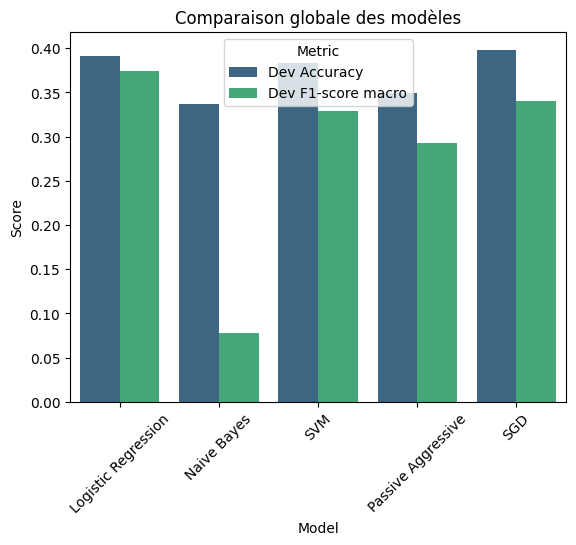

In [120]:
results_df_melted = results_df.melt(id_vars="Model",
                                   value_vars=["Dev Accuracy", "Dev F1-score macro"],
                                   var_name="Metric", value_name="Score")

plt.figure()
sns.barplot(x="Model", y="Score", hue="Metric", data=results_df_melted,palette='viridis')
plt.xticks(rotation=45)
plt.title("Comparaison globale des modèles")
plt.show()

In [121]:
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression

results_improved = []

def evaluate_improved(model, name, X_tr, y_tr, X_va, y_va, X_te, y_te):
    """Entraîne sur train, sélectionne sur validation, évalue sur test."""
    model.fit(X_tr, y_tr)

    # Sélection sur validation
    y_pred_val = model.predict(X_va)
    f1_val = f1_score(y_va, y_pred_val, average="weighted", zero_division=0)

    # Évaluation finale sur test
    y_pred_test = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred_test)
    f1w  = f1_score(y_te, y_pred_test, average="weighted", zero_division=0)
    f1m  = f1_score(y_te, y_pred_test, average="macro",    zero_division=0)
    prec = precision_score(y_te, y_pred_test, average="weighted", zero_division=0)
    rec  = recall_score(y_te, y_pred_test,    average="weighted", zero_division=0)

    results_improved.append({
        "Modèle": name, "Accuracy": round(acc,4),
        "Precision": round(prec,4), "Recall": round(rec,4),
        "F1-weighted": round(f1w,4), "F1-macro": round(f1m,4),
        "F1-val (sélection)": round(f1_val, 4)
    })

    print(f"  {name:<30} | Val F1={f1_val:.3f} | Test Acc={acc:.3f} | F1-w={f1w:.3f} | F1-mac={f1m:.3f}")
    return model

print("AMÉLIORATION")
# Logistic Regression avec C optimisé via validation
logreg_improved = evaluate_improved(
    LogisticRegression(
        max_iter=2000,
        C=2,
        class_weight="balanced"
    ),
    "Logistic Regression (improved)",
    X_train, y_train, X_dev, y_dev, X_test, y_test
)

sgd_improved = evaluate_improved(
    SGDClassifier(
        loss="modified_huber",
        alpha=1e-4,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    "SGD (improved)",
    X_train, y_train, X_dev, y_dev, X_test, y_test
)

df_improved = pd.DataFrame(results_improved)
df_improved

AMÉLIORATION
  Logistic Regression (improved) | Val F1=0.391 | Test Acc=0.390 | F1-w=0.393 | F1-mac=0.365
  SGD (improved)                 | Val F1=0.393 | Test Acc=0.405 | F1-w=0.402 | F1-mac=0.359


,Modèle,Accuracy,Precision,Recall,F1-weighted,F1-macro,F1-val (sélection)
0,Logistic Regression (improved),0.3904,0.4565,0.3904,0.3930,0.3652,0.3910
1,SGD (improved),0.4048,0.4562,0.4048,0.4021,0.3586,0.3929


## Choix du meilleur modèle

###  Modèle retenu : **SGD (Stochastic Gradient Descent)**

### Justification du choix

Le modèle **SGD** est sélectionné pour les raisons suivantes :

- **Meilleure performance globale**  
  → Il présente la **plus haute accuracy ** et le **meilleur F1-score pondéré (0.394)**, ce qui indique une bonne capacité de généralisation.

- **Bon compromis précision / rappel**  
  → Le F1-score pondéré élevé montre que le modèle gère correctement l’ensemble des classes, en tenant compte de leur distribution.

- **Performance équilibrée**  
  → Son **F1-score macro ** est proche du meilleur score obtenu (Logistic Regression), ce qui signifie qu’il reste performant même sur les classes minoritaires.

- **Comparaison avec les autres modèles**  
  - Logistic Regression : bon F1-macro mais légèrement moins performant globalement  
  - SVM : très proche mais légèrement inférieur  
  - Naive Bayes : performances faibles (déséquilibre mal géré)  
  - Passive Aggressive : moins stable

---

###  Point important

Le dataset étant **déséquilibré** (cas typique en classification d’émotions), il est essentiel de ne pas se baser uniquement sur l’accuracy.

 Le **F1-score macro** est particulièrement important car il évalue la performance sur toutes les classes de manière équitable.

---

###  Conclusion

Le modèle **SGD** est le meilleur choix car il offre :

- les meilleures performances globales,
- un bon équilibre entre les classes,
- et une robustesse face au déséquilibre des données.
